In [1]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

devie = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available:",devie)

Device Available: cpu


In [2]:
# Reading the Data
image_path = []
labels = []

#read image path and label
for i in os.listdir("../../data/raw/afhq/"):
    for label in os.listdir(f"../../data/raw/afhq/{i}"):
        for image in os.listdir(f"../../data/raw/afhq/{i}/{label}"):
            image_path.append(f"../../data/raw/afhq/{i}/{label}/{image}")
            labels.append(label)
            

data_df = pd.DataFrame(zip(image_path,labels), columns=["image_path","labels"])

print(data_df["labels"].unique())
data_df.head()

<StringArray>
['cat', 'dog', 'wild']
Length: 3, dtype: str


,image_path,labels
0,../../data/raw/afhq/val/cat/flickr_cat_000653.jpg,cat
1,../../data/raw/afhq/val/cat/pixabay_cat_000756...,cat
2,../../data/raw/afhq/val/cat/pixabay_cat_003038...,cat
3,../../data/raw/afhq/val/cat/pixabay_cat_004237...,cat
4,../../data/raw/afhq/val/cat/pixabay_cat_002117...,cat


In [3]:
# Spliting the Data into Training, testing and Validation, testing  (Not using train_test_split)
# We have combined the data from traing and testing folder of afhq, that is why we are spliting

# Using Sample method, it will give random sample

train = data_df.sample(frac=0.7)
test = data_df.drop(train.index)     # droping train and remaining for test

validation = test.sample(frac=0.5)
test = test.drop(validation.index)

print(train.shape)
print(test.shape)
print(validation.shape)

(11291, 2)
(2419, 2)
(2420, 2)


In [4]:
# Label Concoding, using to convert the labels to number

label_encoder = LabelEncoder()
label_encoder.fit(data_df['labels'])

# It makes all the images to have same properties, like size, datatype  

transform = transforms.Compose([
            transforms.Resize((128,128)),
            transforms.ToTensor(),
            transforms.ConvertImageDtype(torch.float)    
])


In [5]:
# Creating a custom Image Dataset for pytorch

class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform = None):
        self.dataframe = dataframe
        self.transform = transform
        
        #convert the labels to tensor, by transforming using encoder and passing to tensor
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(devie)

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        image_path = self.dataframe.iloc[idx,0]
        label = self.labels[idx]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image).to(devie)

        return image, label


In [6]:
#Creating custom datasets 

train_dataset = CustomImageDataset(dataframe=train, transform=transform)
validation_dataset = CustomImageDataset(dataframe=validation, transform=transform)
test_dataset = CustomImageDataset(dataframe=test, transform=transform)

In [7]:
# for my understanding let check image and currosponding label

print(train_dataset.__len__() )
print(label_encoder.inverse_transform([1]))
train_dataset.__getitem__(0)


11291
['dog']


(tensor([[[0.3373, 0.3333, 0.3333,  ..., 0.4627, 0.4667, 0.4627],
          [0.3373, 0.3333, 0.3373,  ..., 0.4627, 0.4667, 0.4627],
          [0.3373, 0.3373, 0.3373,  ..., 0.4706, 0.4706, 0.4627],
          ...,
          [0.3059, 0.3137, 0.3137,  ..., 0.5922, 0.5922, 0.5961],
          [0.3255, 0.3216, 0.3176,  ..., 0.5882, 0.5882, 0.5882],
          [0.3255, 0.3294, 0.3294,  ..., 0.5882, 0.5882, 0.5882]],
 
         [[0.2980, 0.2863, 0.2745,  ..., 0.3451, 0.3451, 0.3373],
          [0.2980, 0.2902, 0.2824,  ..., 0.3451, 0.3451, 0.3373],
          [0.2980, 0.2902, 0.2824,  ..., 0.3529, 0.3490, 0.3373],
          ...,
          [0.3098, 0.3176, 0.3176,  ..., 0.5922, 0.5922, 0.5961],
          [0.3294, 0.3255, 0.3216,  ..., 0.5882, 0.5882, 0.5882],
          [0.3294, 0.3333, 0.3333,  ..., 0.5882, 0.5882, 0.5882]],
 
         [[0.2941, 0.2824, 0.2627,  ..., 0.2784, 0.2627, 0.2471],
          [0.2941, 0.2824, 0.2706,  ..., 0.2784, 0.2627, 0.2471],
          [0.2941, 0.2863, 0.2706,  ...,

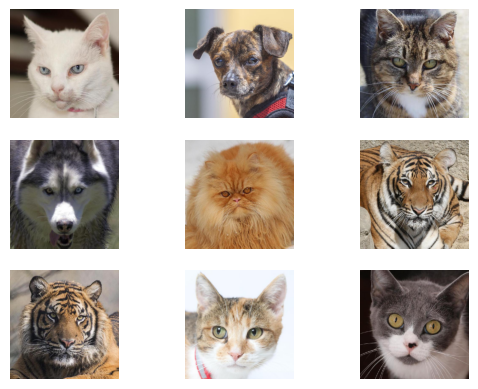

In [8]:
# Check an random images

n_rows = 3
n_cols = 3

fig, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = Image.open(data_df.sample(n=1)['image_path'].iloc[0]).convert("RGB")
        axarr[row,col].imshow(image)
        axarr[row,col].axis('off')
plt.show()

In [9]:
# Setting up the hyperparameters

LR = 1e-4
EPOCH = 10
BATCH_SIZE = 16


train_loder = DataLoader(train_dataset,batch_size=BATCH_SIZE, shuffle=True)
validation_loder = DataLoader(validation_dataset,batch_size=BATCH_SIZE, shuffle=True)
test_loder = DataLoader(test_dataset,batch_size=BATCH_SIZE, shuffle=True)

In [10]:
# Creating the model class

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pooling = nn.MaxPool2d(2,2) #Pooling function
        self.relu = nn.ReLU() #Activation funtion

        self.flatten = nn.Flatten()
        self.liner = nn.Linear((128*16*16), 128) # clearity comes from forward function 
        self.output = nn.Linear(128, len(data_df['labels'].unique()))


    def forward(self, x):
        x = self.conv1(x) #--> (32, 128, 128)
        x = self.pooling(x) #--> (32, 128/2, 128/2)
        x = self.relu(x)

        x = self.conv2(x) #--> (64, 64, 64)
        x = self.pooling(x) #--> (32, 32, 32)
        x = self.relu(x)

        x = self.conv3(x) #--> (128, 32, 32)
        x = self.pooling(x) #--> (128, 16, 16)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.liner(x)
        x = self.output(x)
        return x

In [11]:
model = Net().to(devie)

In [12]:
from torchsummary import summary
summary(model, input_size= (3, 128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [13]:
# Defing the training

criterion = nn.CrossEntropyLoss()    #loss function
optimizer = Adam(model.parameters(),lr=LR)  #Optimizer


#Creating List to store data after each batch to plot and see the traing

total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot =[]

#Loop through each Epoch 
for epoch in range(EPOCH):
    total_loss_train = 0
    total_loss_validation = 0
    total_acc_train = 0
    total_acc_validation = 0

    for inputs, labels in train_loder:
        optimizer.zero_grad()           #helps to reset the optimizer

        # Forward Propogation
        outputs = model(inputs)
        train_loss = criterion(outputs,labels)     # remeber (input, output)
        total_loss_train += train_loss.item()  # get only item not the tensor

        #Backward Propogation
        train_loss.backward()
        
        #Accuracy
        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        total_acc_train += train_acc
        optimizer.step()

    with torch.no_grad():
        for inputs, labels in validation_loder:
            outputs = model(inputs)

            #Forward Propogation
            val_loss = criterion(outputs,labels)
            total_loss_validation += val_loss.item()

            #Accuracy
            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_validation += val_acc
    
    total_loss_train_plot.append(round(total_loss_train/1000,4))
    total_loss_validation_plot.append(round(total_loss_validation/1000, 4))

    total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__() * 100,4))
    total_acc_validation_plot.append(round(total_acc_validation/validation_dataset.__len__() *100,4))

    print(f''' Epoch {epoch+1}/{EPOCH}, Train Loss: {round(total_loss_train/1000,4)}, Train Accuracy {round(total_acc_train/train_dataset.__len__() * 100,4)} 
    Validation loss: {round(total_loss_validation/1000, 4)}, Validation Accuracy: {round(total_acc_validation/validation_dataset.__len__() *100,4)}   ''')

 Epoch 1/10, Train Loss: 0.3438, Train Accuracy 79.3287 
    Validation loss: 0.0357, Validation Accuracy: 91.6116   
 Epoch 2/10, Train Loss: 0.1356, Train Accuracy 93.0387 
    Validation loss: 0.0265, Validation Accuracy: 94.0496   
 Epoch 3/10, Train Loss: 0.0908, Train Accuracy 95.5097 
    Validation loss: 0.021, Validation Accuracy: 95.1653   
 Epoch 4/10, Train Loss: 0.0665, Train Accuracy 96.8116 
    Validation loss: 0.0196, Validation Accuracy: 95.3719   
 Epoch 5/10, Train Loss: 0.0493, Train Accuracy 97.3519 
    Validation loss: 0.0188, Validation Accuracy: 95.9091   
 Epoch 6/10, Train Loss: 0.0364, Train Accuracy 98.2021 
    Validation loss: 0.0178, Validation Accuracy: 95.8678   
 Epoch 7/10, Train Loss: 0.0249, Train Accuracy 98.8132 
    Validation loss: 0.0223, Validation Accuracy: 95.5785   
 Epoch 8/10, Train Loss: 0.0186, Train Accuracy 99.0523 
    Validation loss: 0.0177, Validation Accuracy: 96.4876   
 Epoch 9/10, Train Loss: 0.0122, Train Accuracy 99.4332 


In [14]:
# Testing the Data
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0

    for inputs, labels in test_loder:
        predictions = model(inputs)

        acc = (torch.argmax(predictions, axis=1)==labels).sum().item()
        total_acc_test += acc
        test_loss = criterion(predictions,labels)      
        total_loss_test += test_loss.item()

    print(f"Accuracy Score {round(total_acc_test/test_dataset.__len__() * 100,4)}, and Loss is {round(total_loss_test/1000,4)} ")


Accuracy Score 95.7834, and Loss is 0.0227 


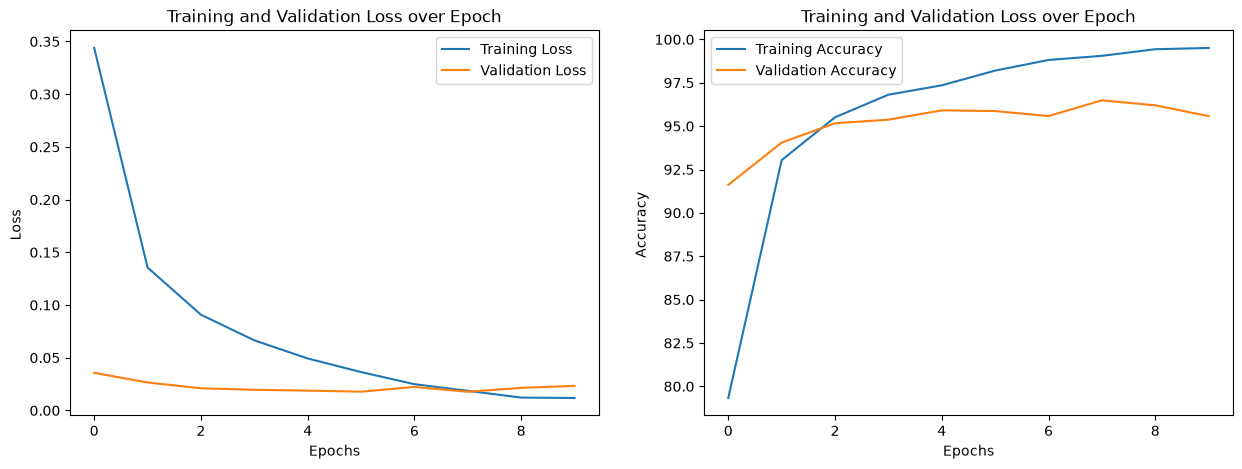

In [30]:
# Plotting the Training Progress

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

axs[0].plot(total_loss_train_plot, label="Training Loss")
axs[0].plot(total_loss_validation_plot, label="Validation Loss")
axs[0].set_title("Training and Validation Loss over Epoch")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss ")
axs[0].legend()


axs[1].plot(total_acc_train_plot, label="Training Accuracy")
axs[1].plot(total_acc_validation_plot, label="Validation Accuracy")
axs[1].set_title("Training and Validation Loss over Epoch")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy ")
axs[1].legend()

plt.show()

In [35]:
### Model Inferance

# Read the image
# Transfrom using transform object
# predict through the model
# inverse transform using label encoder

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image)

    output = model(image.unsqueeze(0))  # it helps to add batch number in image as our model has trained with batches,img size is imp.

    output = torch.argmax(output, axis=1).item()
    return label_encoder.inverse_transform([output]) 

In [36]:
predict_image("istockphoto-1443562748-612x612.jpg")

array(['cat'], dtype=object)